In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA = Path.home() / "Desktop/Classes/Smirnov_Research Project/defi-perps/data/raw/dydx"

btc = pd.read_parquet(DATA / "BTC-USD_funding.parquet")
eth = pd.read_parquet(DATA / "ETH-USD_funding.parquet")
sol = pd.read_parquet(DATA / "SOL-USD_funding.parquet")

df = pd.concat([btc, eth, sol], ignore_index=True)
df = df.sort_values(["market", "timestamp"]).reset_index(drop=True)

print(f"Total rows: {len(df):,}")
print(f"\nPer market:")
print(df.groupby("market")["timestamp"].agg(["count", "min", "max"]))

Total rows: 7,185

Per market:
         count                              min  \
market                                            
BTC-USD   2395 2023-10-27 00:00:00.858000+00:00   
ETH-USD   2395 2023-10-27 00:00:00.858000+00:00   
SOL-USD   2395 2023-10-27 00:00:00.858000+00:00   

                                     max  
market                                    
BTC-USD 2025-12-30 16:00:00.045000+00:00  
ETH-USD 2025-12-30 16:00:00.045000+00:00  
SOL-USD 2025-12-30 16:00:00.045000+00:00  


In [2]:
# ratio = P_tk / I_tk  (candle close / oracle price)
print("Ratio P_tk / I_tk by market:")
print(df.groupby("market")["ratio"].describe().round(6))
print(f"\nNaN ratios: {df['ratio'].isna().sum()} / {len(df)}")

Ratio P_tk / I_tk by market:
          count      mean       std       min       25%       50%       75%  \
market                                                                        
BTC-USD  2342.0  1.000178  0.005205  0.951264  0.997903  1.000023  1.002518   
ETH-USD  2342.0  1.000241  0.007502  0.939462  0.996940  1.000240  1.003570   
SOL-USD  2340.0  1.000019  0.010247  0.936071  0.995176  1.000113  1.005023   

              max  
market             
BTC-USD  1.045048  
ETH-USD  1.094661  
SOL-USD  1.093134  

NaN ratios: 161 / 7185


In [3]:
print(df['f_tk'].describe())
print(df['rate_8h'].describe())
print("ratio:", (df['f_tk'] / df['rate_8h']).dropna().unique()[:5])

count    7185.000000
mean        0.000017
std         0.000030
min        -0.000210
25%         0.000000
50%         0.000010
75%         0.000026
max         0.000379
Name: f_tk, dtype: float64
count    7185.000000
mean        0.000017
std         0.000030
min        -0.000210
25%         0.000000
50%         0.000010
75%         0.000026
max         0.000379
Name: rate_8h, dtype: float64
ratio: [1.]


In [4]:
print("Total NaN ratios:", df['ratio'].isna().sum(), "out of", len(df))
print("NaN by market:")
print(df.groupby('market')['ratio'].apply(lambda x: x.isna().sum()))
print("\nEarliest non-NaN ratio:")
print(df[df['ratio'].notna()]['timestamp'].min())

Total NaN ratios: 161 out of 7185
NaN by market:
market
BTC-USD    53
ETH-USD    53
SOL-USD    55
Name: ratio, dtype: int64

Earliest non-NaN ratio:
2023-11-13 16:00:01.402000+00:00


In [5]:
# Pick one row and verify manually
row = df[df['market']=='BTC-USD'].iloc[0]
print("timestamp:  ", row['timestamp'])
print("rate_8h:    ", row['rate_8h'])
print("f_tk:       ", row['f_tk'])
print("f_tk*10000: ", row['f_tk']*10000, "bps")
print("eta*10000:  ", row['eta']*10000, "bps")
print("% of cap:   ", abs(row['f_tk'])/row['eta']*100, "%")

timestamp:   2023-10-27 00:00:00.858000+00:00
rate_8h:     0.0
f_tk:        0.0
f_tk*10000:  0.0 bps
eta*10000:   60.0 bps
% of cap:    0.0 %


In [6]:
SPLIT = pd.Timestamp("2025-01-01", tz="UTC")

train = df[df["timestamp"] < SPLIT].copy()
test  = df[df["timestamp"] >= SPLIT].copy()

print(f"Training (2023-2024): {len(train):,} rows")
print(f"Test     (2025):      {len(test):,} rows")
print()
print(train.groupby("market")["timestamp"].agg(["count", "min", "max"]))
print()
print(test.groupby("market")["timestamp"].agg(["count", "min", "max"]))

Training (2023-2024): 3,912 rows
Test     (2025):      3,273 rows

         count                              min  \
market                                            
BTC-USD   1304 2023-10-27 00:00:00.858000+00:00   
ETH-USD   1304 2023-10-27 00:00:00.858000+00:00   
SOL-USD   1304 2023-10-27 00:00:00.858000+00:00   

                                     max  
market                                    
BTC-USD 2024-12-31 16:00:00.204000+00:00  
ETH-USD 2024-12-31 16:00:00.204000+00:00  
SOL-USD 2024-12-31 16:00:00.204000+00:00  

         count                              min  \
market                                            
BTC-USD   1091 2025-01-01 00:00:01.057000+00:00   
ETH-USD   1091 2025-01-01 00:00:01.057000+00:00   
SOL-USD   1091 2025-01-01 00:00:01.057000+00:00   

                                     max  
market                                    
BTC-USD 2025-12-30 16:00:00.045000+00:00  
ETH-USD 2025-12-30 16:00:00.045000+00:00  
SOL-USD 2025-12-30 16:00:00.04500

In [7]:
gammas     = {}
gamma_dist = {}
headroom   = {}

for market, grp in train.groupby("market"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)

    next_perp   = grp["ratio"].shift(-1) * grp["oracle_price"].shift(-1)
    next_oracle = grp["oracle_price"].shift(-1)
    basis       = (next_perp - next_oracle).abs().dropna()

    gamma              = np.percentile(basis, 99)
    gammas[market]     = gamma
    gamma_dist[market] = basis

    eta    = grp["eta"].iloc[0]
    mean_I = grp["oracle_price"].mean()
    hr     = gamma / (eta * mean_I)
    headroom[market] = hr

    print(f"{market}")
    print(f"  Gamma (99th pct)       = {gamma:,.4f} USD")
    print(f"  eta_1h                 = {eta:.6f}  ({eta*1e4:.2f} bps)")
    print(f"  eta_1h * mean_I        = {eta * mean_I:,.4f} USD")
    print(f"  Headroom Gamma/(eta*I) = {hr:.4f}  {'[NON-EMPTY]' if hr > 1 else '[DEGENERATE]'}")
    print()

BTC-USD
  Gamma (99th pct)       = 1,290.3777 USD
  eta_1h                 = 0.006000  (60.00 bps)
  eta_1h * mean_I        = 371.0369 USD
  Headroom Gamma/(eta*I) = 3.4778  [NON-EMPTY]

ETH-USD
  Gamma (99th pct)       = 80.4087 USD
  eta_1h                 = 0.006000  (60.00 bps)
  eta_1h * mean_I        = 17.4186 USD
  Headroom Gamma/(eta*I) = 4.6163  [NON-EMPTY]

SOL-USD
  Gamma (99th pct)       = 6.2301 USD
  eta_1h                 = 0.015000  (150.00 bps)
  eta_1h * mean_I        = 2.1261 USD
  Headroom Gamma/(eta*I) = 2.9302  [NON-EMPTY]



In [8]:
KAPPA_F = 0.0
KAPPA_S = 0.0010
R       = 0.0
R_C     = 0.0

for market in ["BTC-USD", "ETH-USD", "SOL-USD"]:
    grp    = test[test["market"] == market]
    gamma  = gammas[market]
    eta    = grp["eta"].iloc[0]
    mean_I = grp["oracle_price"].mean()

    L = (1 - KAPPA_S + eta - gamma / mean_I)
    U = (1 + KAPPA_S - eta + gamma / mean_I)
    width = U - L

    print(f"{market}:")
    print(f"  mean oracle price = {mean_I:,.0f}")
    print(f"  L = {L:.6f}  U = {U:.6f}")
    print(f"  band width = {width*1e4:.1f} bps")
    print()

BTC-USD:
  mean oracle price = 101,666
  L = 0.992308  U = 1.007692
  band width = 153.8 bps

ETH-USD:
  mean oracle price = 3,067
  L = 0.978781  U = 1.021219
  band width = 424.4 bps

SOL-USD:
  mean oracle price = 170
  L = 0.977394  U = 1.022606
  band width = 452.1 bps



In [9]:
def compute_bounds(oracle_price, eta, gamma, kappa_F=KAPPA_F, kappa_S=KAPPA_S, r=R, r_C=R_C):
    dL = 1.0 + kappa_F * (1.0 + r)
    dU = 1.0 - kappa_F * (1.0 + r)
    cL = (1.0 - kappa_S) * (1.0 + r) / (1.0 + r_C)
    cU = (1.0 + kappa_S) * (1.0 + r) / (1.0 + r_C)
    L  = (cL + eta - gamma / oracle_price) / dL
    U  = (cU - eta + gamma / oracle_price) / dU
    return L, U

results = []
for market, grp in test.groupby("market"):
    grp   = grp.sort_values("timestamp").copy()
    gamma = gammas[market]

    grp["L_tk"], grp["U_tk"] = zip(*grp.apply(
        lambda r: compute_bounds(r["oracle_price"], r["eta"], gamma), axis=1))

    grp["band_width"]  = grp["U_tk"] - grp["L_tk"]
    grp["degenerate"]  = grp["band_width"] < 0

    lower_v = grp["lower_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] < grp["L_tk"])
    upper_v = grp["upper_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] > grp["U_tk"])
    grp["violation"]       = lower_v | upper_v
    grp["lower_violation"] = lower_v
    grp["upper_violation"] = upper_v
    grp["viol_mag"]        = np.maximum(
        grp["L_tk"] - grp["ratio"],
        grp["ratio"] - grp["U_tk"]
    ).clip(lower=0)

    results.append(grp)

test_out = pd.concat(results, ignore_index=True)

print("=" * 55)
print("TEST 1 RESULTS — dYdX violation test (2025)")
print("=" * 55)
for market, grp in test_out.groupby("market"):
    n      = len(grp)
    n_clamp = grp["clamped"].sum()
    n_viol  = grp["violation"].sum()
    print(f"\n{market}:")
    print(f"  Total obs    : {n}")
    print(f"  Clamped      : {n_clamp} ({n_clamp/n*100:.1f}%)")
    print(f"  Violations   : {n_viol}")
    print(f"  Mean band    : {grp['band_width'].mean()*1e4:.1f} bps")

TEST 1 RESULTS — dYdX violation test (2025)

BTC-USD:
  Total obs    : 1091
  Clamped      : 0 (0.0%)
  Violations   : 0
  Mean band    : 157.4 bps

ETH-USD:
  Total obs    : 1091
  Clamped      : 0 (0.0%)
  Violations   : 0
  Mean band    : 472.5 bps

SOL-USD:
  Total obs    : 1091
  Clamped      : 0 (0.0%)
  Violations   : 0
  Mean band    : 483.4 bps


In [10]:
# Show how close rates got to the cap
for market, grp in test_out.groupby("market"):
    eta = grp["eta"].iloc[0]
    max_rate = grp["f_tk"].abs().max()
    print(f"{market}: max |f_tk| = {max_rate*1e4:.2f} bps  vs  eta = {eta*1e4:.0f} bps  ({max_rate/eta*100:.1f}% of cap)")

BTC-USD: max |f_tk| = 0.98 bps  vs  eta = 60 bps  (1.6% of cap)
ETH-USD: max |f_tk| = 1.18 bps  vs  eta = 60 bps  (2.0% of cap)
SOL-USD: max |f_tk| = 2.10 bps  vs  eta = 150 bps  (1.4% of cap)


In [11]:
print("=" * 60)
print("TEST 1 RESULTS — Ratio P_tk/I_tk inside no-arbitrage bounds")
print("=" * 60)

summary = []
for market, grp in test_out.groupby("market"):
    n_obs      = len(grp)
    n_clamped  = grp["clamped"].sum()
    n_viol     = grp["violation"].sum()
    viol_rate  = n_viol / n_clamped if n_clamped > 0 else float("nan")
    mean_width = grp["band_width"].mean()
    viol_mag   = grp[grp["violation"]]["viol_mag"]
    mean_mag   = viol_mag.mean() if len(viol_mag) > 0 else 0
    runs, dur  = [], 0
    for v in grp.sort_values("timestamp")["violation"]:
        if v:   dur += 1
        elif dur > 0: runs.append(dur); dur = 0
    if dur > 0: runs.append(dur)
    mean_dur = np.mean(runs) if runs else 0
    summary.append({
        "Market":          market,
        "Total obs":       n_obs,
        "Clamped obs":     n_clamped,
        "Violations":      n_viol,
        "Violation rate":  f"{viol_rate*100:.2f}%" if n_clamped > 0 else "N/A",
        "Mean magnitude":  f"{mean_mag*1e4:.1f} bps",
        "Mean duration":   f"{mean_dur:.1f} periods",
        "Mean band width": f"{mean_width*1e4:.1f} bps",
    })
print(pd.DataFrame(summary).to_string(index=False))
print()
print("Note: 1 period = 8 hours on dYdX (vs ~1 hour on Drift)")

TEST 1 RESULTS — Ratio P_tk/I_tk inside no-arbitrage bounds
 Market  Total obs  Clamped obs  Violations Violation rate Mean magnitude Mean duration Mean band width
BTC-USD       1091            0           0            N/A        0.0 bps   0.0 periods       157.4 bps
ETH-USD       1091            0           0            N/A        0.0 bps   0.0 periods       472.5 bps
SOL-USD       1091            0           0            N/A        0.0 bps   0.0 periods       483.4 bps

Note: 1 period = 8 hours on dYdX (vs ~1 hour on Drift)


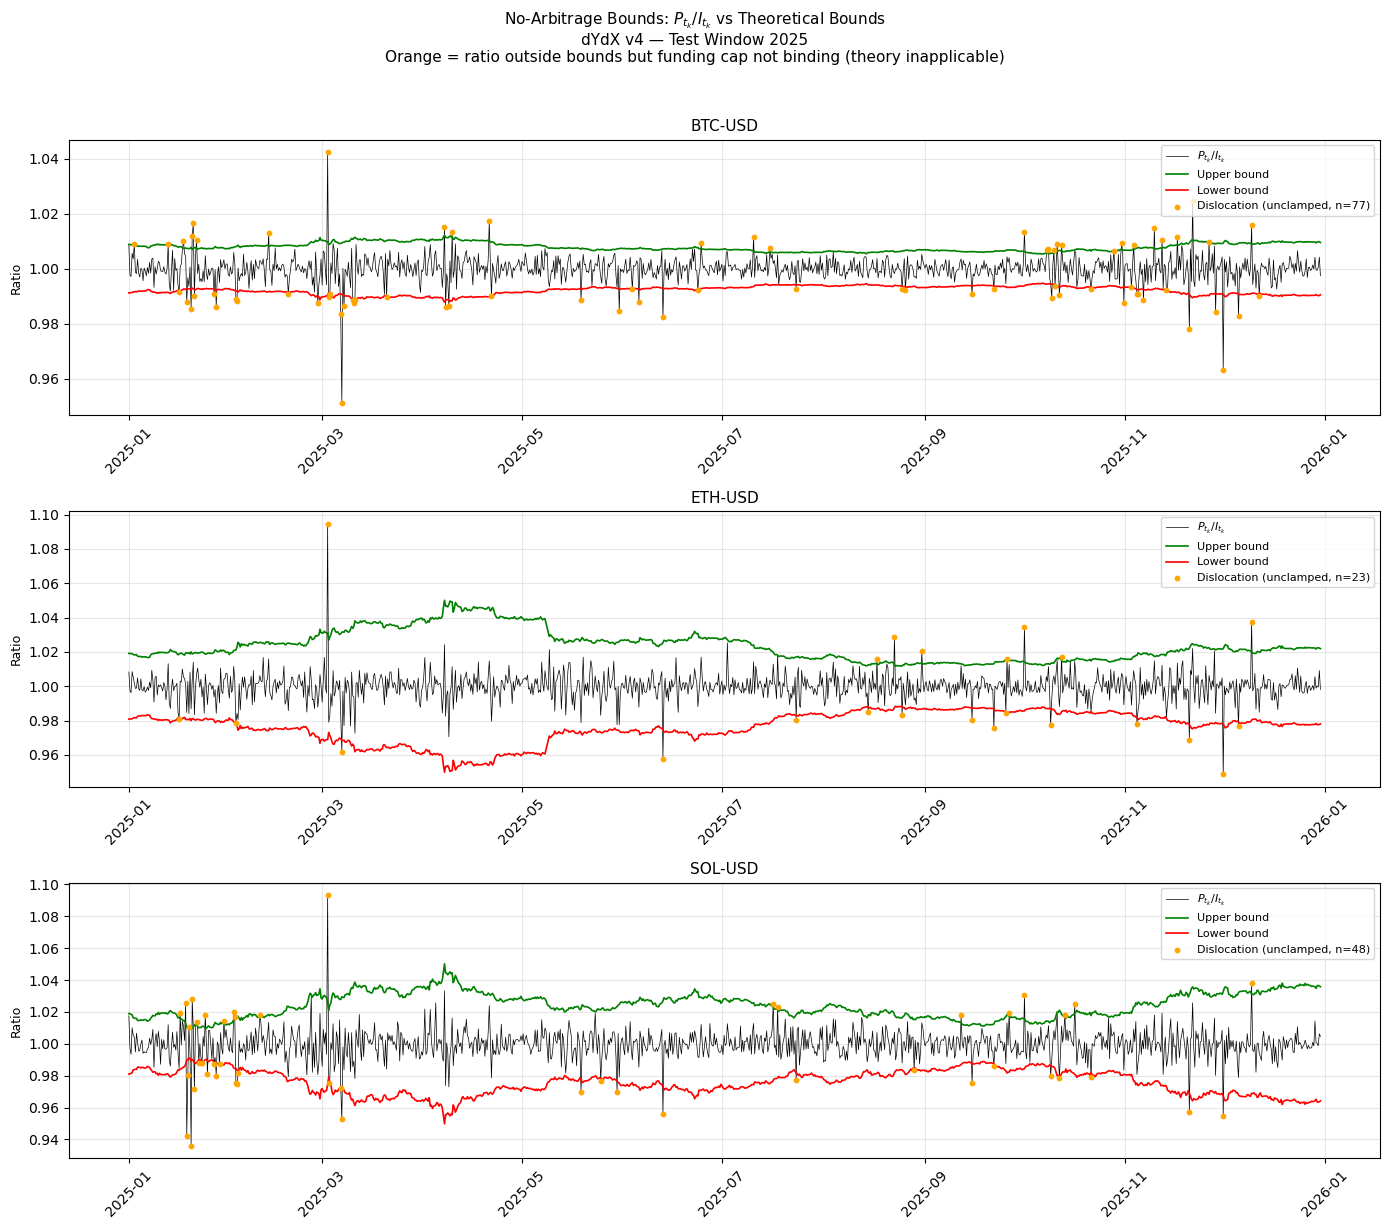

In [12]:
FIGURES = Path.home() / "Desktop/Classes/Smirnov_Research Project/defi-perps/dydx/analysis"
FIGURES.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, market in zip(axes, ["BTC-USD", "ETH-USD", "SOL-USD"]):
    grp = test_out[test_out["market"] == market].sort_values("timestamp")

    ax.plot(grp["timestamp"], grp["ratio"],
            color="black", linewidth=0.5, label="$P_{t_k}/I_{t_k}$")
    ax.plot(grp["timestamp"], grp["U_tk"],
            color="green", linewidth=1.2, linestyle="-", label="Upper bound")
    ax.plot(grp["timestamp"], grp["L_tk"],
            color="red", linewidth=1.2, linestyle="-", label="Lower bound")

    # Clamped violations (theory applies, bound breached)
    clamped_viols = grp[grp["violation"]]
    if len(clamped_viols) > 0:
        ax.scatter(clamped_viols["timestamp"], clamped_viols["ratio"],
                   color="red", s=10, zorder=5, label="Violation (clamped)")

    # Unclamped dislocations (ratio outside bounds but cap not binding)
    unclamped_disloc = grp[
        ~grp["clamped"] &
        grp["ratio"].notna() &
        ((grp["ratio"] < grp["L_tk"]) | (grp["ratio"] > grp["U_tk"]))
    ]
    if len(unclamped_disloc) > 0:
        ax.scatter(unclamped_disloc["timestamp"], unclamped_disloc["ratio"],
                   color="orange", s=10, zorder=5,
                   label=f"Dislocation (unclamped, n={len(unclamped_disloc)})")

    ax.set_title(market, fontsize=11)
    ax.set_ylabel("Ratio", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "No-Arbitrage Bounds: $P_{t_k}/I_{t_k}$ vs Theoretical Bounds\n"
    "dYdX v4 — Test Window 2025\n"
    "Orange = ratio outside bounds but funding cap not binding (theory inapplicable)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES / "figure1_bounds_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

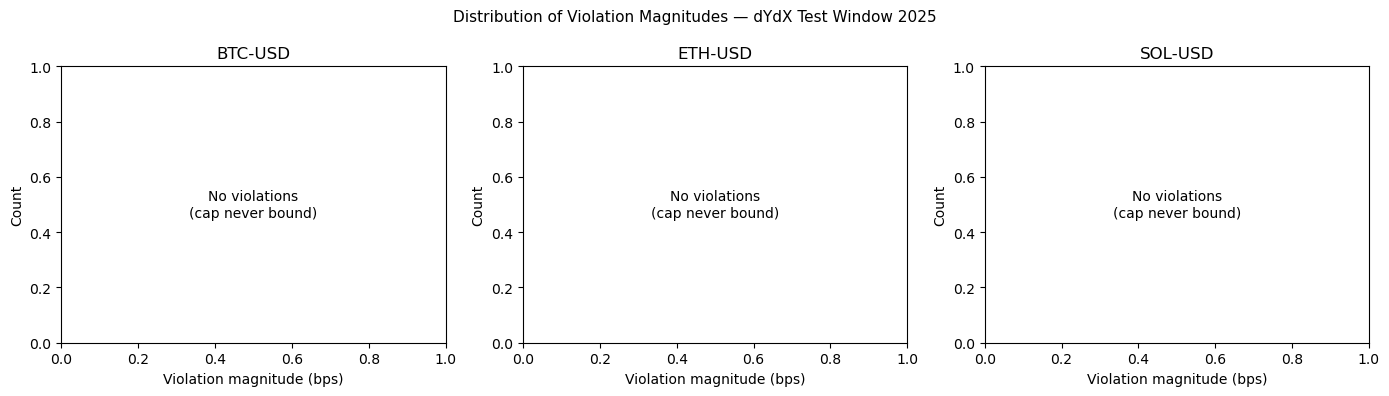

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, market in zip(axes, ["BTC-USD", "ETH-USD", "SOL-USD"]):
    grp      = test_out[test_out["market"] == market]
    viol_mag = grp[grp["violation"]]["viol_mag"] * 1e4
    if len(viol_mag) > 0:
        ax.hist(viol_mag, bins=30, color="steelblue", edgecolor="white")
        ax.axvline(viol_mag.mean(), color="red", linestyle="--",
                   label=f"Mean={viol_mag.mean():.1f} bps")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No violations\n(cap never bound)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title(market)
    ax.set_xlabel("Violation magnitude (bps)")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Violation Magnitudes — dYdX Test Window 2025", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "figure2_violation_magnitudes.png", dpi=150, bbox_inches="tight")
plt.show()

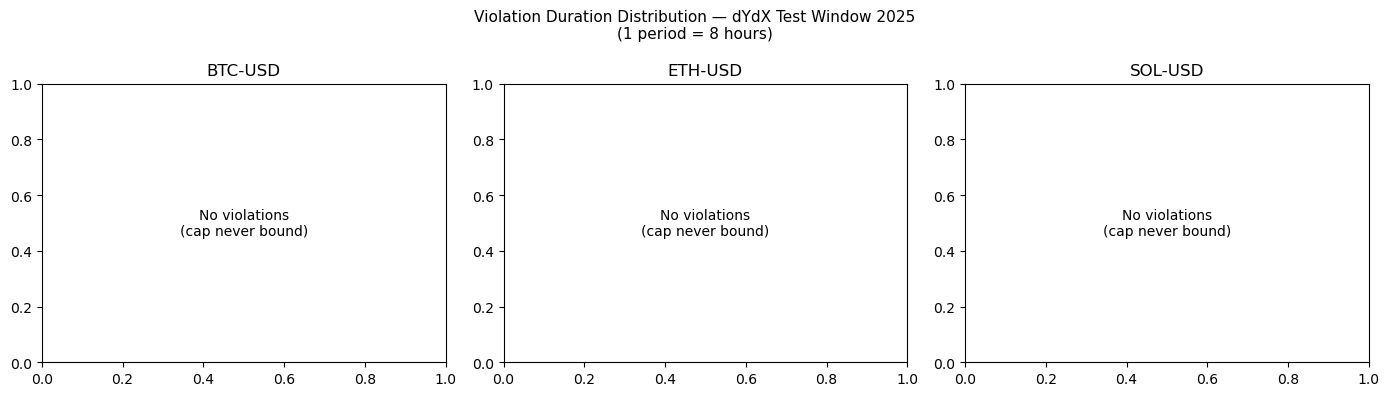

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, market in zip(axes, ["BTC-USD", "ETH-USD", "SOL-USD"]):
    grp  = test_out[test_out["market"] == market].sort_values("timestamp")
    runs, dur = [], 0
    for v in grp["violation"]:
        if v:   dur += 1
        elif dur > 0: runs.append(dur); dur = 0
    if dur > 0: runs.append(dur)
    if runs:
        ax.bar(range(1, len(runs)+1), sorted(runs, reverse=True),
               color="steelblue", edgecolor="white")
        ax.axhline(np.mean(runs), color="red", linestyle="--",
                   label=f"Mean={np.mean(runs):.1f} periods")
        ax.legend(fontsize=8)
        ax.set_xlabel("Violation episode")
        ax.set_ylabel("Duration (8h periods)")
    else:
        ax.text(0.5, 0.5, "No violations\n(cap never bound)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title(market)

plt.suptitle("Violation Duration Distribution — dYdX Test Window 2025\n(1 period = 8 hours)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "figure3_violation_durations.png", dpi=150, bbox_inches="tight")
plt.show()

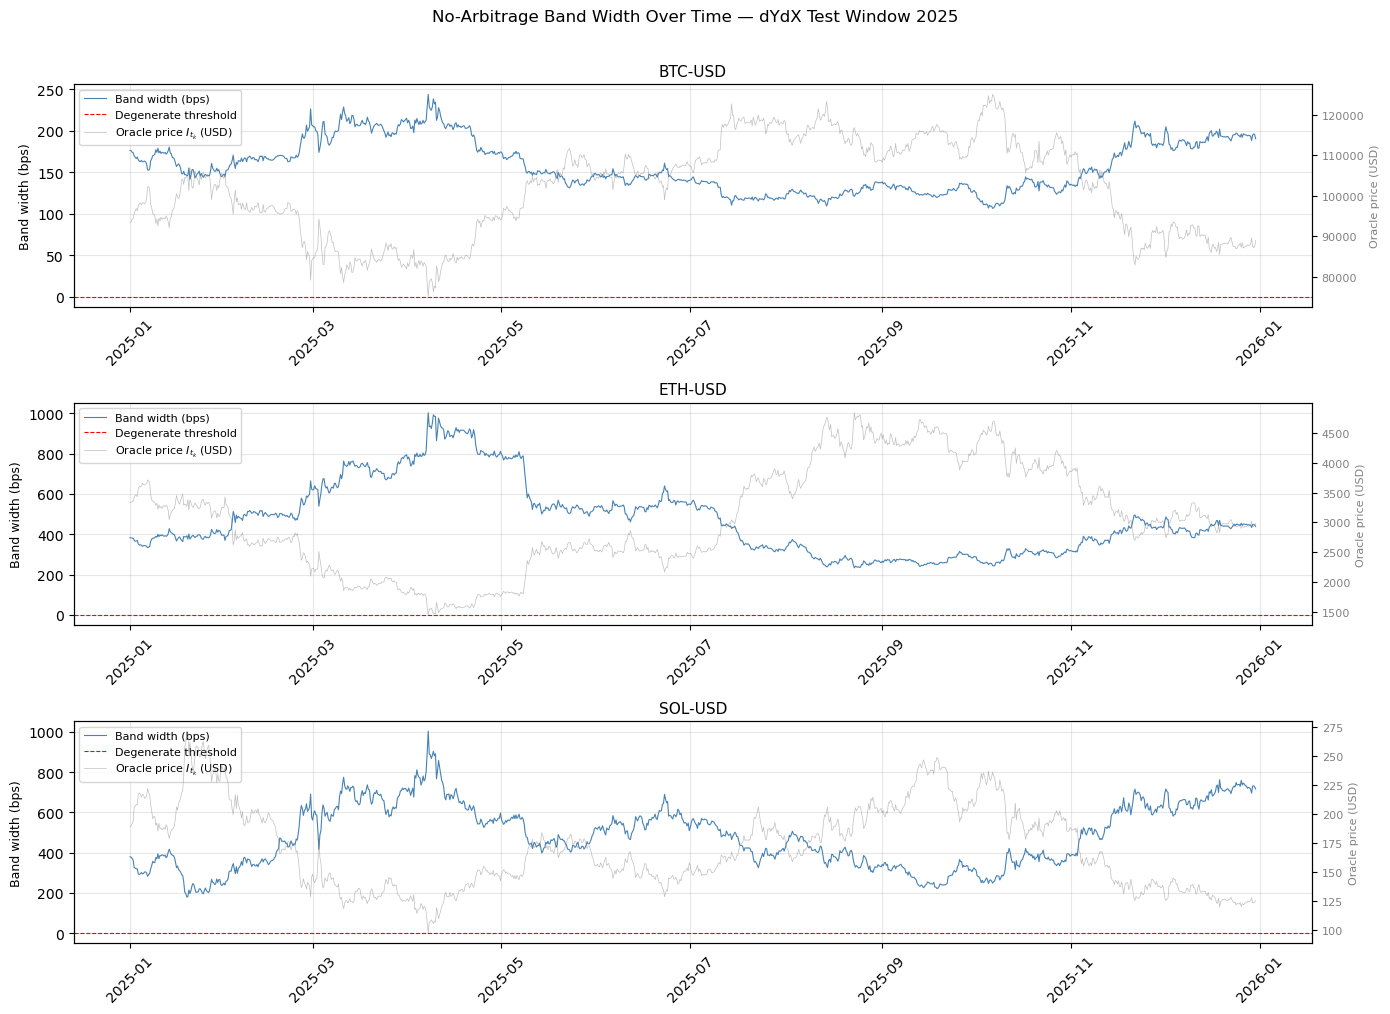

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
for ax, market in zip(axes, ["BTC-USD", "ETH-USD", "SOL-USD"]):
    grp = test_out[test_out["market"] == market].sort_values("timestamp")

    line_band, = ax.plot(grp["timestamp"], grp["band_width"] * 1e4,
                         color="steelblue", linewidth=0.8, label="Band width (bps)")
    line_degen = ax.axhline(0, color="red", linewidth=0.8, linestyle="--",
                            label="Degenerate threshold")

    ax2 = ax.twinx()
    line_oracle, = ax2.plot(grp["timestamp"], grp["oracle_price"],
                            color="gray", linewidth=0.5, alpha=0.5,
                            label=r"Oracle price $I_{t_k}$ (USD)")
    ax2.set_ylabel("Oracle price (USD)", color="gray", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="gray", labelsize=8)

    ax.set_title(market, fontsize=11)
    ax.set_ylabel("Band width (bps)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

    # Combined legend from both axes
    handles = [line_band, line_degen, line_oracle]
    ax.legend(handles=handles, fontsize=8, loc="upper left")

plt.suptitle("No-Arbitrage Band Width Over Time — dYdX Test Window 2025", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "figure4_band_width.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
print("=" * 60)
print("ROBUSTNESS — Violation rates under different Gamma levels")
print("=" * 60)

for pct in [0.99, 0.95, 0.90]:
    gammas_pct = {}
    for market, grp in train.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        next_perp   = grp["ratio"].shift(-1) * grp["oracle_price"].shift(-1)
        next_oracle = grp["oracle_price"].shift(-1)
        basis       = (next_perp - next_oracle).abs().dropna()
        gammas_pct[market] = np.percentile(basis, pct * 100)

    rows_pct = []
    for market, grp in test.groupby("market"):
        grp   = grp.sort_values("timestamp").copy()
        gamma = gammas_pct[market]
        grp["L_tk"], grp["U_tk"] = zip(*grp.apply(
            lambda r: compute_bounds(r["oracle_price"], r["eta"], gamma), axis=1))
        grp["band_width"] = grp["U_tk"] - grp["L_tk"]
        grp["degenerate"] = grp["band_width"] < 0
        lower_v = grp["lower_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] < grp["L_tk"])
        upper_v = grp["upper_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] > grp["U_tk"])
        grp["violation"] = lower_v | upper_v
        rows_pct.append(grp)

    out_pct = pd.concat(rows_pct, ignore_index=True)
    print(f"\nGamma = {int(pct*100)}th percentile:")
    for market, grp in out_pct.groupby("market"):
        g = gammas_pct[market]
        n_clamp = grp["clamped"].sum()
        n_viol  = grp["violation"].sum()
        rate    = n_viol / n_clamp if n_clamp > 0 else float("nan")
        print(f"  {market}: Gamma={g:.4f}  violation rate={rate*100:.2f}%  (clamped={n_clamp})")

ROBUSTNESS — Violation rates under different Gamma levels

Gamma = 99th percentile:
  BTC-USD: Gamma=1290.3777  violation rate=nan%  (clamped=0)
  ETH-USD: Gamma=80.4087  violation rate=nan%  (clamped=0)
  SOL-USD: Gamma=6.2301  violation rate=nan%  (clamped=0)

Gamma = 95th percentile:
  BTC-USD: Gamma=698.8972  violation rate=nan%  (clamped=0)
  ETH-USD: Gamma=42.1630  violation rate=nan%  (clamped=0)
  SOL-USD: Gamma=3.0998  violation rate=nan%  (clamped=0)

Gamma = 90th percentile:
  BTC-USD: Gamma=530.6213  violation rate=nan%  (clamped=0)
  ETH-USD: Gamma=29.1940  violation rate=nan%  (clamped=0)
  SOL-USD: Gamma=2.2606  violation rate=nan%  (clamped=0)


In [17]:
print("=" * 60)
print("ROBUSTNESS — Violation rates under different fee assumptions")
print("=" * 60)

fee_scenarios = [
    ("Zero fees (theoretical)",              0.0,    0.0   ),
    ("Baseline (kF=0 maker, kS=10bps)",      0.0,    0.0010),
    ("Conservative (taker+spot 10bps each)", 0.0005, 0.0010),
    ("Stress (both taker 10bps)",            0.0010, 0.0010),
]

for label, kF, kS in fee_scenarios:
    rows_fee = []
    for market, grp in test.groupby("market"):
        grp   = grp.sort_values("timestamp").copy()
        gamma = gammas[market]
        grp["L_tk"], grp["U_tk"] = zip(*grp.apply(
            lambda r: compute_bounds(r["oracle_price"], r["eta"], gamma, kF, kS), axis=1))
        grp["band_width"] = grp["U_tk"] - grp["L_tk"]
        grp["degenerate"] = grp["band_width"] < 0
        lower_v = grp["lower_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] < grp["L_tk"])
        upper_v = grp["upper_clamped"] & ~grp["degenerate"] & grp["ratio"].notna() & (grp["ratio"] > grp["U_tk"])
        grp["violation"] = lower_v | upper_v
        rows_fee.append(grp)
    out_fee = pd.concat(rows_fee, ignore_index=True)
    print(f"\n{label}  (kF={kF*1e4:.1f}bps, kS={kS*1e4:.1f}bps):")
    for market, grp in out_fee.groupby("market"):
        n_clamp = grp["clamped"].sum()
        n_viol  = grp["violation"].sum()
        rate    = n_viol / n_clamp if n_clamp > 0 else float("nan")
        print(f"  {market}: {rate*100:.2f}%  (clamped={n_clamp})")

ROBUSTNESS — Violation rates under different fee assumptions

Zero fees (theoretical)  (kF=0.0bps, kS=0.0bps):
  BTC-USD: nan%  (clamped=0)
  ETH-USD: nan%  (clamped=0)
  SOL-USD: nan%  (clamped=0)

Baseline (kF=0 maker, kS=10bps)  (kF=0.0bps, kS=10.0bps):
  BTC-USD: nan%  (clamped=0)
  ETH-USD: nan%  (clamped=0)
  SOL-USD: nan%  (clamped=0)

Conservative (taker+spot 10bps each)  (kF=5.0bps, kS=10.0bps):
  BTC-USD: nan%  (clamped=0)
  ETH-USD: nan%  (clamped=0)
  SOL-USD: nan%  (clamped=0)

Stress (both taker 10bps)  (kF=10.0bps, kS=10.0bps):
  BTC-USD: nan%  (clamped=0)
  ETH-USD: nan%  (clamped=0)
  SOL-USD: nan%  (clamped=0)


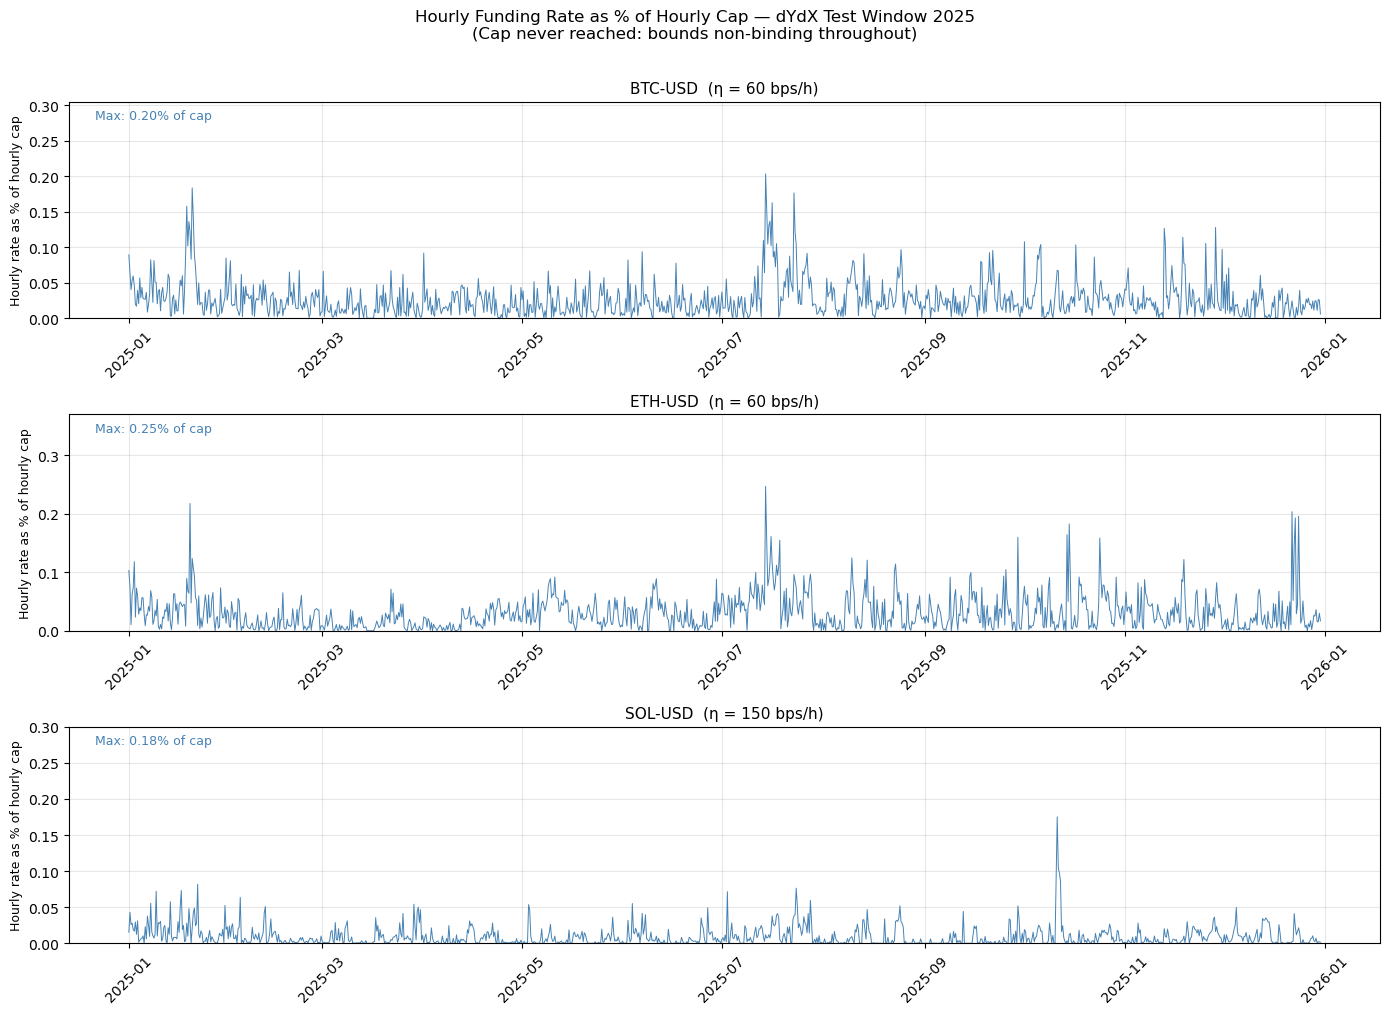

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
for ax, market in zip(axes, ["BTC-USD", "ETH-USD", "SOL-USD"]):
    grp     = test_out[test_out["market"] == market].sort_values("timestamp")
    eta     = grp["eta"].iloc[0]
    pct_cap = (grp["f_tk"].abs() / 8.0) / eta * 100  # hourly rate / hourly cap
    ax.plot(grp["timestamp"], pct_cap, color="steelblue", linewidth=0.7)
    ax.set_title(f"{market}  (η = {eta*1e4:.0f} bps/h)", fontsize=11)
    ax.set_ylabel("Hourly rate as % of hourly cap", fontsize=9)
    ax.set_ylim(0, max(pct_cap.max() * 1.5, 0.3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Max: {pct_cap.max():.2f}% of cap",
                xy=(0.02, 0.92), xycoords="axes fraction", fontsize=9, color="steelblue")

plt.suptitle("Hourly Funding Rate as % of Hourly Cap — dYdX Test Window 2025\n"
             "(Cap never reached: bounds non-binding throughout)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "figure5_pct_of_cap.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# TABLE 1: Ratio stats (mirrors tab:ratio_stats in Drift)
print("Ratio P_tk/I_tk — Full Sample (2023–2025)")
print(df.groupby("market")["ratio"].describe().round(6).to_string())

Ratio P_tk/I_tk — Full Sample (2023–2025)
          count      mean       std       min       25%       50%       75%       max
market                                                                               
BTC-USD  2342.0  1.000178  0.005205  0.951264  0.997903  1.000023  1.002518  1.045048
ETH-USD  2342.0  1.000241  0.007502  0.939462  0.996940  1.000240  1.003570  1.094661
SOL-USD  2340.0  1.000019  0.010247  0.936071  0.995176  1.000113  1.005023  1.093134


In [20]:
# TABLE 2: Gamma calibration (mirrors tab:gamma_calib in Drift)
print("Gamma Calibration — 99th percentile, training window 2023–2024")
for market in ["BTC-USD", "ETH-USD", "SOL-USD"]:
    g = gammas[market]
    mean_I = train[train["market"] == market]["oracle_price"].mean()
    print(f"{market}: Gamma={g:.4f} USD  |  Gamma/mean_I = {g/mean_I*100:.4f}%")

Gamma Calibration — 99th percentile, training window 2023–2024
BTC-USD: Gamma=1290.3777 USD  |  Gamma/mean_I = 2.0867%
ETH-USD: Gamma=80.4087 USD  |  Gamma/mean_I = 2.7698%
SOL-USD: Gamma=6.2301 USD  |  Gamma/mean_I = 4.3954%


In [21]:
# TABLE 3: Unclamped dislocations (new — specific to dYdX, no Drift equivalent)
print("Unclamped basis dislocations — ratio outside bounds but cap not binding")
for market, grp in test_out.groupby("market"):
    disloc = grp[
        ~grp["clamped"] & grp["ratio"].notna() &
        ((grp["ratio"] < grp["L_tk"]) | (grp["ratio"] > grp["U_tk"]))
    ]
    n_obs = grp["ratio"].notna().sum()
    print(f"{market}: {len(disloc)} dislocations / {n_obs} obs ({len(disloc)/n_obs*100:.1f}%)")
    print(f"  max downside: {(grp['L_tk'] - grp['ratio']).clip(lower=0).max()*1e4:.1f} bps below lower bound")
    print(f"  max upside:   {(grp['ratio'] - grp['U_tk']).clip(lower=0).max()*1e4:.1f} bps above upper bound")

Unclamped basis dislocations — ratio outside bounds but cap not binding
BTC-USD: 77 dislocations / 1091 obs (7.1%)
  max downside: 393.8 bps below lower bound
  max upside:   325.8 bps above upper bound
ETH-USD: 23 dislocations / 1091 obs (2.1%)
  max downside: 293.8 bps below lower bound
  max upside:   635.8 bps above upper bound
SOL-USD: 48 dislocations / 1091 obs (4.4%)
  max downside: 532.1 bps below lower bound
  max upside:   675.6 bps above upper bound


In [22]:
# TABLE 4: Cap proximity (key dYdX finding — no Drift equivalent)
print("Maximum funding rate as % of cap — test window 2025")
for market, grp in test_out.groupby("market"):
    eta = grp["eta"].iloc[0]
    max_rate = grp["f_tk"].abs().max()
    print(f"{market}: max|f_tk|={max_rate*1e4:.2f} bps  eta={eta*1e4:.0f} bps  ({max_rate/eta*100:.1f}% of cap)")

Maximum funding rate as % of cap — test window 2025
BTC-USD: max|f_tk|=0.98 bps  eta=60 bps  (1.6% of cap)
ETH-USD: max|f_tk|=1.18 bps  eta=60 bps  (2.0% of cap)
SOL-USD: max|f_tk|=2.10 bps  eta=150 bps  (1.4% of cap)
